In [140]:
import argparse
from pathlib import Path
from typing import Iterable
import pandas as pd
import numpy as np
import drms
import os
import re
import math

from dotenv import load_dotenv

import matplotlib.pyplot as plt
from astropy.io import fits

AIA_MAP = {
    "aia94": 94,
    "aia131": 131,
    "aia171": 171,
    "aia193": 193,
    "aia211": 211,
    "aia304": 304,
    "aia335": 335
}

HMI_MAP = {
    "hmi_m": ("hmi.M_720s", "magnetogram"),
    "hmi_bx": ("hmi.B_720s", "field"),
    "hmi_by": ("hmi.B_720s", "inclination"),
    "hmi_bz": ("hmi.B_720s", "azimuth"),
    "hmi_v": ("hmi.V_720s", "Dopplergram"),
}

load_dotenv("../../.env")
if os.path.isfile("../../.env.local"):
    load_dotenv("../../.env.local")

In [141]:
data_folder=Path("../../data/notebooks/data_fetch_sdo")
data_folder.mkdir(parents=True, exist_ok=True)

def _download_data(q):
    c = drms.Client(email=os.getenv("SDO_EMAIL"))
    export = c.export(
        q,
        method="url_quick",
        protocol="fits"
    )
    export.wait()
    
    export.download(data_folder)

def _download_aia(stamp):
    missed_wavelengths = []
    
    for k,wavelength in AIA_MAP.items():
        # For dev we look only for one specific file as marker
        expectedFileName = f"aia.lev1_euv_12s.2026-01-01T115925Z.94.image_lev1.fits"
        
        if not os.path.isfile(data_folder / expectedFileName):
            missed_wavelengths.append(wavelength)

    if len(missed_wavelengths) == 0:
        return

    w_q = ",".join(map(str, missed_wavelengths))
    q = f"aia.lev1_euv_12s[{stamp}][{w_q}]{{image}}"
    # For dev we just download all
    q = f"aia.lev1_euv_12s[{stamp}]{{image}}"
    
    _download_data(q)
    
def _download_hmi(stamp):
    requested_frames = dict()
    for k,(series, segment) in HMI_MAP.items():
        expectedFileName = "hmi.b_720s.20260101_120000_TAI.field.fits"
        
        if not os.path.isfile(data_folder / expectedFileName):
            if not requested_frames.get(series):
                requested_frames[series] = []
            requested_frames[series].append(segment)

    if not requested_frames:
        return

    for series, segments in requested_frames.items():
        req_series = []
        for segment in segments:
            req_series.append(f"{series}[{stamp}]{{{segment}}}")

        segment_q = ",".join(segments)
        q = f"{series}[{stamp}]{{{segment_q}}}"
        print(q)
        
        #_download_data(q)
        
    
def download_all_observations():
    stamp="2026.01.01_12:00:00_TAI"

    _download_aia(stamp)
    _download_hmi(stamp)

download_all_observations()

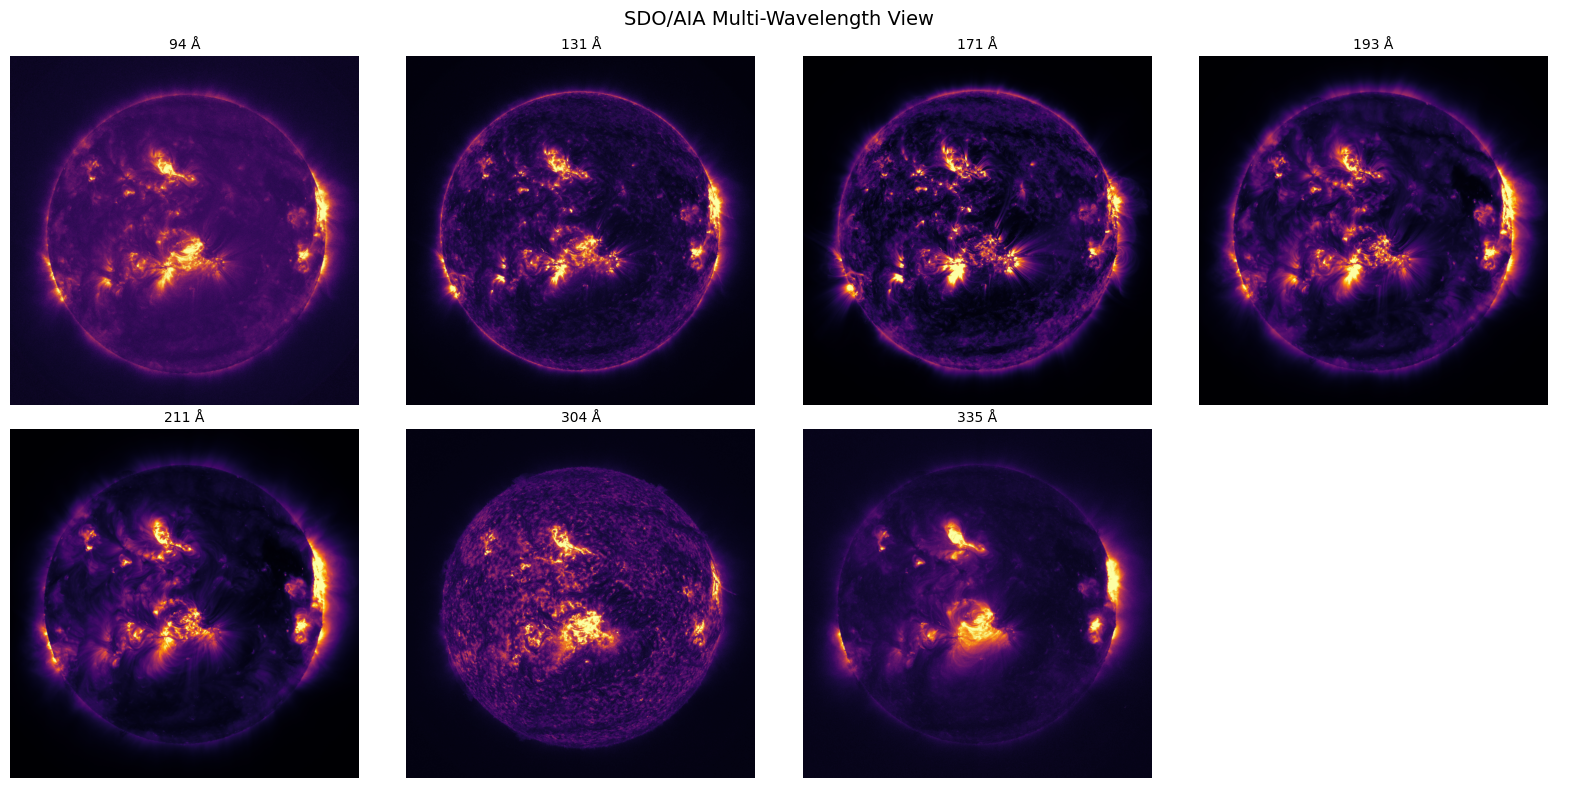

In [151]:
def _show_aia():
    def get_aia_wavelength(path):
        for k, w in AIA_MAP.items():
            if f".{w}." in path.name:
                return w
        return -1

    def load_aia(f):
        with fits.open(f) as hdul:
            img = hdul[1].data.astype(float)
            
        img = np.nan_to_num(img)
        vmin, vmax = np.percentile(img, (1, 99.5))
        return np.clip(img, vmin, vmax)
    
    aia_files = [
        f for f in data_folder.glob("*.fits")
        if get_aia_wavelength(f) != -1
    ]

    aia_files = sorted(
        aia_files,
        key=get_aia_wavelength
    )
    aia_files = aia_files[:7]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, f in enumerate(aia_files):
        img = load_aia(f)

        with fits.open(f) as hdul:
            header = hdul[1].header
        
        axes[i].imshow(img, cmap="inferno", origin="lower")
        axes[i].set_title(f"{f.name.split('.')[-3]} Å", fontsize=10)
        axes[i].axis("off")

    for j in range(7, len(axes)):
        axes[j].axis("off")

    plt.suptitle("SDO/AIA Multi-Wavelength View", fontsize=14)
    plt.tight_layout()
    plt.show()

_show_aia()


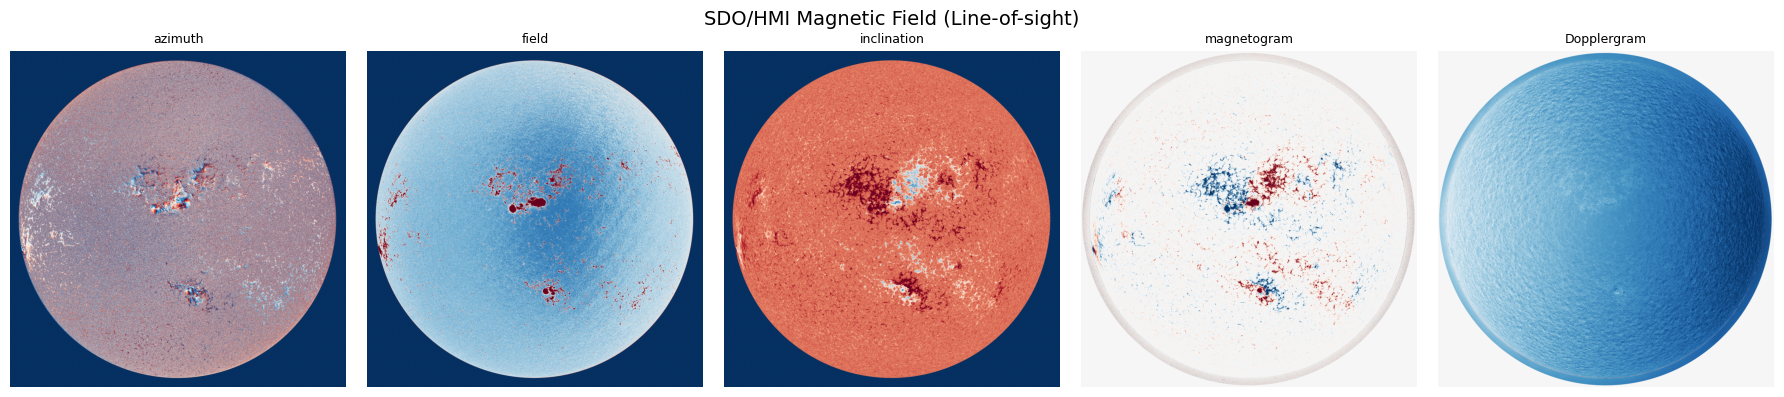

In [148]:
def _show_hmi():
    def load_hmi(f):
        with fits.open(f) as hdul:
            img = hdul[1].data
    
        img = np.nan_to_num(img).astype(float)
    
        vmax = np.nanpercentile(np.abs(img), 99)
        return np.clip(img, -vmax, vmax)
    
    hmi_files = sorted([
        f for f in data_folder.glob("*.fits")
        if "hmi" in f.name
    ])[:5]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    axes = axes.flatten()
    
    for i, f in enumerate(hmi_files):
        with fits.open(f) as hdul:
            img = load_hmi(f)
    
        axes[i].imshow(img, cmap="RdBu_r", origin="lower")
        axes[i].set_title(f.name.split(".")[-2], fontsize=9)
        axes[i].axis("off")

    plt.suptitle("SDO/HMI Magnetic Field (Line-of-sight)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
_show_hmi()